In [453]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from matplotlib import colors
import matplotlib.pyplot as plt
import numpy as np
import glob
### importing toy datasets
sys.path.insert(0,'/hdd/miles/velocity_cfm/dnnlib')
from util import Vanderpol,DoubleCircles,DoubleSDE,Lorenz63,Lorenz96,Rossler,projection,Balls,ToyDsetDynamics
from vae import AutoEncoder,LatentVAE,LatentAC

### importing comparison models
sys.path.insert(0,'/hdd/miles/velocity_cfm/lfads')
import lfads
from run_lfads import train, flags, hps_dict_to_obj

import tphate
import cebra

def make_lfads_dict(flags_dict,true_dim,data_dim,dist='gaussian'):
    # output parameters
    flags_dict['output_dist'] = dist
    # generation parameters
    flags_dict['ic_dim'] = 32 #initial conditions dimension
    flags_dict['factors_dim'] = true_dim # output of generator, priod to decoding
    flags_dict['ic_enc_dim'] = 64 #hidden dimension of encoding RNN

    flags_dict['gen_dim'] = 50 # hidden dimension of generator RNN

    flags_dict['ci_enc_dim'] = 32 # hidden size for encoder of control inputs
    flags_dict['con_dim'] =  32 # hidden size of controller
    
    flags_dict['batch_size']= 64
    flags_dict['lfads_save_dir'] = '/home/miles/isilon/All_Staff/miles/comparison_lfads_circles_updated_smaller'
    

    return hps_dict_to_obj(flags_dict)

%matplotlib inline

### model comparison functions

In [506]:
def format_data_comparisons(train,test,gt_train,gt_test,T=1,dt=0.01,name='Circles',latent_dim=2,short_train_n=40):

    #lfads_train,lfads_test = np.stack(train,axis=0),np.stack(test,axis=0)
    #lfads_dataset = {'train_data': lfads_train,'valid_data': lfads_test,'data_dim':3,'num_steps':lfads_train.shape[1],
    #      'train_ext_input':np.zeros(lfads_train.shape),'valid_ext_input':np.zeros(lfads_test.shape)}

    #hps = make_lfads_dict(flags.FLAGS.flag_values_dict(),true_dim=gt_train[0].shape[-1],data_dim=train[0].shape[-1])
    
    # need to use fewer trials for tphate, only works for training data. cap at 50 samples
    if len(train) > short_train_n: 
        order = np.random.choice(len(train), short_train_n,replace=False)
        tphate_train = np.reshape(train[order,...],(-1,train.shape[-1]))
    else:
        order = np.arange(0,len(train))
        tphate_train = np.reshape(train,(-1,train.shape[-1]))

    tphate_test = np.vstack(test)

    cebra_train,cebra_test = np.reshape(train,(-1,train.shape[-1])),np.reshape(test,(-1,test.shape[-1]))
    cebra_labels_train,cebra_labels_test = np.hstack([np.arange(0,T-dt/2,dt) for _ in range(len(train))]),\
    np.hstack([np.arange(0,T-dt/2,dt) for _ in range(len(test))])

    vae_train,vae_test = ToyDsetDynamics([np.log(t/dt) for t in train],dt=dt,nForward=0),ToyDsetDynamics([np.log(t/dt) for t in test],dt=dt,nForward=0)
    vae_train_dl = torch.utils.data.DataLoader(vae_train,batch_size=1024,num_workers=4,shuffle=True)
    vae_test_dl = torch.utils.data.DataLoader(vae_test,batch_size=1024,num_workers=4,shuffle=False)

    #dmd_train,dmd_test = format_data_dmd(train,test,d=10)
    dataDict = {
                #'lfads':{'data':{name:lfads_dataset},'hyperparameters':hps}, ## add in hyperparameters
                'tphate':{'train':tphate_train,
                          'test':tphate_test,
                          'train_indices':order,
                          'train_shape':(short_train_n,gt_train.shape[1],latent_dim),
                          'test_shape':(gt_test.shape[0],gt_test.shape[1],latent_dim)},
                'cebra':{'train': (cebra_train,cebra_labels_train),
                         'test':(cebra_test,cebra_labels_test),
                        'train_shape': (gt_train.shape[0],gt_train.shape[1],latent_dim),
                         'test_shape':(gt_test.shape[0],gt_test.shape[1],latent_dim)},
                'vae': {'train': vae_train_dl,
                        'test':vae_test_dl},
                'dmd': {'train':np.log(tphate_train/dt),
                        'test':np.log(tphate_test/dt),
                        'train_indices':order,
                       'train_shape':(short_train_n,gt_train.shape[1],latent_dim),
                        'test_shape':(gt_test.shape[0],gt_test.shape[1],latent_dim)},
                'ground truth': {'train': gt_train,
                                 'test':gt_test},
                'projections': {'train':[np.log(t/dt) for t in train],
                                'test':[np.log(t/dt) for t in test]},
                'true_dim': gt_train[0].shape[-1],
                'latent_dim':latent_dim,
                'data_dim': train[0].shape[-1],
                'name': name
    }

    return dataDict


In [502]:
import time
def compare_models(data_dict):


    print('training dmd')
    dmd_model,dmd_train_e,dmd_test_e = train_dmd(data_dict['dmd'],n=data_dict['latent_dim'])
    print('training vae')
    vae_model,vae_train_e,vae_test_e = train_vae(data_dict['vae'],latent_dim=data_dict['latent_dim'],data_dim=data_dict['data_dim'],orig_train=data_dict['projections']['train'],orig_test=data_dict['projections']['test'],beta=1e-2,\
                                                 save_dir=f'/home/miles/isilon/All_Staff/miles/comparison_models/vae_comparisons/{data_dict["name"]}')
    print("training tphate")
    tphate_model,tphate_train_e,tphate_test_e = train_tphate(data_dict['tphate'],n_components=data_dict['latent_dim'],name=data_dict['name'])
    print("training cebra")
    start = time.time()
    cebra_model,cebra_train_e,cebra_test_e = train_cebra(data_dict['cebra'],n=data_dict['latent_dim'],name=data_dict['name'])
    length = time.time() - start
    print(f"trained/cross-validated cebra in {np.round(length,2)} s")
    gt_train,gt_test = data_dict['ground truth']['train'],data_dict['ground truth']['test']


    return [vae_model,cebra_model,dmd_model,tphate_model],\
            [gt_train,vae_train_e,cebra_train_e,dmd_train_e,tphate_train_e],\
            [gt_test,vae_test_e,cebra_test_e,dmd_test_e,tphate_test_e]


    #plot_models(gt_train,lfads_train_e,tphate_train_e,cebra_train_e,names=['lfads','tphate','cebra'])


### plotting function (edit alpha_fnc for non-circle models)

In [524]:
%matplotlib inline
import matplotlib.colors
font = {'family':'serif','serif':['Palatino'],'size':10}
plt.rc('font',**font)
plt.rc('text',usetex=True)
def plot_models(ground_truth,*embeddings,names=[],label='train_comparison.svg',generator=None):


    if generator:
        xlims = (np.amin(ground_truth[:,:,1])-0.5,np.amax(ground_truth[:,:,1])+0.5)
        ylims = (np.amin(ground_truth[:,:,0])-0.5,np.amax(ground_truth[:,:,0])+0.5)
        x,y = np.meshgrid(np.arange(xlims[0],xlims[1],np.diff(xlims)/20),np.arange(ylims[0],ylims[1],np.diff(ylims)/20))
        xys = np.vstack([x.flatten(),y.flatten()]).T

        dxs = np.vstack([generator.dx(xy,t=0,dt=0.01,sigma=0) for xy in xys])
        

    
    nAx = len(embeddings) + 1
    
    dim_gt = ground_truth.shape[-1]
    dim_lats = embeddings[0].shape[-1]
    
    projection_gt = None if dim_gt == 2 else '3d'
    projection_lats = None if dim_lats == 2 else '3d'
    fig = plt.figure(figsize=(25,7))#plt.subplots(nrows=1,ncols=nAx,subplot_kw={'projection':projection},figsize=(25,7))
    axs = [fig.add_subplot(1,nAx,1,projection=projection_gt)] + [fig.add_subplot(1,nAx,ii+2,projection=projection_lats,computed_zorder=False) for ii in range(len(embeddings))]
    cm = plt.get_cmap('viridis')

    
    cs = np.linalg.norm(ground_truth,axis=-1)
    if type(generator) == type(DoubleCircles()):
        alpha_fnc = lambda x: np.clip(np.abs(x - 3.5)*0.1,a_min=0,a_max=0.1)
    else:
        alpha_fnc = lambda x: 0.1*np.ones(x.shape)
    #print(alpha_fnc(np.array([3.5])))
    norm = colors.Normalize(vmin = np.amin(cs)-0.25,vmax=np.amax(cs)+0.25)
    cs_true = cm(norm(cs))
    #print(cs_true.shape)
    #print(cs.shape)
    cs_true = np.stack([np.stack([c[:,0],c[:,1],c[:,2],alpha_fnc(n)],axis=1) for c,n in zip(cs_true,cs)],axis=0)
    #print(cs_true.shape)
    for sample,c in zip(ground_truth,cs_true):
        if dim_gt ==2:
            axs[0].scatter(sample[:,0],sample[:,1],zorder=-2,c=c,s=1)#,alpha=0.1) map='viridis',norm=norm,
        else:
            axs[0].scatter(sample[:,0],sample[:,1],sample[:,2],zorder=-2,c=c,s=1) #norm=norm,,cmap='viridis',alpha=0.1
    if generator:
        axs[0].quiver(xys[:,0],xys[:,1],dxs[:,0],dxs[:,1],angles='xy',zorder=-3)
    axs[0].set_title('Ground Truth',fontsize=18)
    axs[0].set_rasterization_zorder(-1)
    axs[0].axis('square')
    axs[0].axis('off')
    for ii,embed in enumerate(embeddings):
        ax = axs[ii+1] #fig.add_subplot(1,nAx,ii+2,projection=projection)
        if type(embed) == tuple:
            embed,indices = embed
            c2 = cs_true[indices]
        else:
            c2 = cs_true
        if len(embed.shape) == 2:
            embed = embed[None,:,:]
        #print(embed.shape)
        for sample,c in zip(embed,c2):
            #c2 = np.linalg.norm(sample,axis=-1)
            if dim_lats == 2:
                ax.scatter(sample[:,0],sample[:,1],zorder=-3,c=c,s=1,alpha=0.1)
            else:
                ax.scatter(sample[:,0],sample[:,1],sample[:,2],zorder=-3,c=c,s=1,alpha=0.1)

        ax.set_rasterization_zorder(-1)
        ax.set_title(names[ii],fontsize=18)
        ax.axis('off')
        ax.axis('square')

    #plt.axis('off')
    plt.tight_layout()
    plt.savefig(label,transparent=True)
    plt.savefig(label.split('.svg')[0] + '.pdf',transparent=True)
    plt.show()
    plt.close()

### Train LFADS (do not use)

In [16]:
import tensorflow as tf

class HiddenPrints:
    def __enter__(self):
        self._original_stdout=sys.stdout
        sys.stdout = open(os.devnull,'w')

    def __exit__(self,exc_type,exc_val,exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

def train_lfads(dataset):

    hps = dataset['hyperparameters']
    datasets = dataset['data']
    hps.kind = 'train'
    hps.dataset_names = []
    hps.dataset_dims = {}
    for key in datasets:
        hps.dataset_names.append(key)
        hps.dataset_dims[key] = datasets[key]['data_dim']
    hps.num_steps = list(datasets.values())[0]['num_steps']
    hps.ndatasets = len(hps.dataset_names)
    if hps.num_steps_for_gen_ic > hps.num_steps:
        hps.num_steps_for_gen_ic = hps.num_steps
    hps._clip_value = 80
    hps.learning_rate_stop = 0.005

    
    config = tf.compat.v1.ConfigProto(allow_soft_placement=True,
                              log_device_placement=False)
    config.gpu_options.allow_growth=True

    sess = tf.compat.v1.Session(config=config)
    print("training or restoring model")
    with sess.as_default():
        with tf.device(hps.device):
            
                model = train(hps,datasets)

    print("getting data embeddings")
    with sess.as_default():
        ds = hps.dataset_names[0]
        with HiddenPrints():
            train_data_dict = model.eval_model_runs_avg_epoch(data_name=list(dataset.keys())[0],data_extxd=datasets[ds]['train_data'])
            test_data_dict = model.eval_model_runs_avg_epoch(data_name=list(dataset.keys())[0],data_extxd=datasets[ds]['valid_data'])

    return model,train_data_dict['factors'],test_data_dict['factors']

### train T-PHATE

In [549]:
import pickle

def save_tphate(model,fn):

    with open(fn,'wb') as f:
        pickle.dump(model,f,pickle.HIGHEST_PROTOCOL)

def load_tphate(fn):

    with open(fn,'rb') as f:
        model = pickle.load(f)
    return model

def train_tphate(dataset,n_components=2,name=''):

    
    saveloc = f"/home/miles/isilon/All_Staff/miles/comparison_models/tphate_comparisons/{name}"
    if not os.path.isdir(saveloc):
        os.mkdir(saveloc)
    fn = os.path.join(saveloc,'tphate.pkl')
    if os.path.isfile(fn):
        print("tphate model exists! loading")
        model = load_tphate(fn)
        train_embedding = model.transform(dataset['train'])
    else:
        model = tphate.TPHATE(n_jobs=4, verbose=1, t='auto', \
                          mds='metric', mds_solver='sgd', smooth_window=2,gamma=1,n_components=n_components)
        train_embedding = model.fit_transform(dataset['train'])
        save_tphate(model,fn)
        
    test_embedding = model.transform(dataset['test'])

    return model,(train_embedding.reshape(dataset['train_shape']),dataset['train_indices']),test_embedding.reshape(dataset['test_shape'])

### VAE training

In [479]:
import torch.nn as nn

def train(model,optimizer,loaders,nEpochs=100,save_freq=25):

    train_losses,test_losses,val_losses = [],[],[]
    for epoch in tqdm(range(nEpochs),desc='training model'):

        model.train()

        train_loss,optimizer = model.train_epoch(loaders['train'],optimizer)

        model.eval()
        val_loss = model.val_epoch(loaders['test'])

        if (epoch+1) % save_freq == 0:
            model.save(optimizer)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return train_losses,val_losses,model,optimizer


def predict(model,trajectory):

    model.eval()
    trajectory = torch.from_numpy(trajectory).type(torch.FloatTensor).to(model.device)[None,...]
    #print(trajectory.shape)
    x = trajectory[:,:-1,...]
    y = trajectory[:,1:,...]

    
    yhat,_ = model(x)

    return yhat.detach().cpu().numpy().squeeze()


def embed(model,trajectory):

    model.eval()
    trajectory = torch.from_numpy(trajectory).type(torch.FloatTensor).to(model.device)[None,...]
    #print(trajectory.shape)
    #z = torch.vmap(model.encoder,in_dims=1,out_dims=1)(trajectory)
    #print(z.shape)
    x = trajectory#[:,,...]
    y = trajectory#[:,1:,...]

    yhat,_ = model.encode(x)
    return yhat.detach().cpu().numpy().squeeze()

In [587]:
from tqdm import tqdm
from torch.optim import Adam

def train_vae(dataset,data_dim,latent_dim,orig_train,orig_test,save_dir='.',beta=1.):

    enc = nn.Sequential(*[nn.Linear(data_dim,6,bias=True),
                     nn.ReLU(),
                     nn.Linear(6,3,bias=True),
                     nn.ReLU(),
                     nn.Linear(3,latent_dim,bias=True)])
    dec = nn.Sequential(*[nn.Linear(latent_dim,3,bias=True),
                     nn.ReLU(),
                     nn.Linear(3,6,bias=True),
                     nn.ReLU(),
                     nn.Linear(6,data_dim,bias=True)])
    latent_model = LatentVAE(input_size=latent_dim,output_size=latent_dim,num_hidden=1,hidden_size=5)
    #latent_model = LatentAC()
    model = AutoEncoder(enc,dec,latent_model=latent_model,save_dir=save_dir,loss_fn = lambda x,y: (1e2*(x-y)**2 ).sum(),beta=beta)

    opt = Adam(model.parameters(),lr=1e-5)
    final_file = os.path.join(save_dir,'checkpoint_600.tar')
    if os.path.isfile(final_file):
        print('loading last checkpoint!')
        model.load(final_file,opt)
    else:
        train_loss,test_loss,model,opt = train(model,opt,dataset,nEpochs=601,save_freq=25)
    
        ax = plt.gca()
        ax.plot(np.hstack(train_loss))
        ax.set_title("train loss")
        plt.show()
        plt.close()
    
        ax = plt.gca()
        ax.plot(np.hstack(test_loss))
        ax.set_title('test loss')
        plt.show()
        plt.close()

    train_embedding = np.stack([embed(model,traj) for traj in orig_train],axis=0)
    test_embedding = np.stack([embed(model,traj) for traj in orig_test],axis=0)

    
    return model,train_embedding,test_embedding

In [584]:
ac,ltr,lte = train_vae(dd['vae'],latent_dim=3,data_dim=4,orig_train=dd['projections']['train'],orig_test=dd['projections']['test'],beta=1e-2,save_dir='/home/miles/Downloads/vae_tmp')

training model:   0%| | 0/301 [00:00<?, ?i


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x16 and 4x6)

In [ ]:
training_data_vae = dd['dmd']['train']
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

ax.scatter(training_data_vae[:,0],training_data_vae[:,1],training_data_vae[:,2])
plt.show()
plt.close()

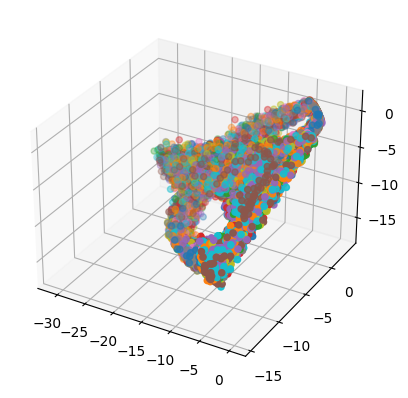

In [414]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

for e in lte:
    ax.scatter(e[:,0],e[:,1],e[:,2])

plt.show()
plt.close()

### Cebra training

In [499]:
def train_cebra(dataset,name='',n=2):

    params_grid = dict(
        output_dimension = [n],
        learning_rate = [1e-3,1e-4],
        time_offsets = [2,5,10,20],
        max_iterations = 10000,
        temperature_mode = "auto",
        verbose = False,
        batch_size=256)

    datasets = {'dataset1': (dataset['train'])}
    saveloc = f"/home/miles/isilon/All_Staff/miles/comparison_models/cebra_comparisons/{name}"
    grid_search = cebra.grid_search.GridSearch()
    if len(glob.glob(os.path.join(saveloc,'*.pt'))) == 0:
        
        grid_search.fit_models(datasets=datasets, params=params_grid, models_dir=saveloc)
    
        df_results = grid_search.get_df_results(models_dir=saveloc)
    best_model, best_model_name = grid_search.get_best_model(dataset_name="dataset1", \
                                                             models_dir=saveloc)

    train_embedding,test_embedding = best_model.transform(dataset['train'][0]), best_model.transform(dataset['test'][0])

    return best_model,train_embedding.reshape(dataset['train_shape']),test_embedding.reshape(dataset['test_shape'])

### DMD training (do use)

In [440]:
from pydmd import DMD,HODMD
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_summary

def train_dmd(dataset,dmd_rank=16,n=2):
    print(dataset['train'].shape)
    model = DMD(dmd_rank)#,d=1)
    #model = HODMD(svd_rank=0, exact=True, opt=True, d=30)
    model.fit(dataset['train'].T)
    #(dataset['train'].shape)
    #model.fit(dataset['train'].T)
    #plot_summary(dmd)
    
    train_embedding = project_modes(model,dataset['train'].T,n=n).T
    test_embedding = project_modes(model,dataset['test'].T,n=n).T
    return model,\
            (np.real(train_embedding.reshape(dataset['train_shape'])),dataset['train_indices']),\
            np.real(test_embedding.reshape(dataset['test_shape']))

def project_modes(dmd,X,n=2):

    modes,eigs = dmd.modes,dmd.eigs
    print(modes.shape)
    print(eigs.shape)
    print(dmd.dynamics.shape)
    modes, eigs = modes[:,:n],eigs[:n]
    #print(X.shape)
    #print(modes[:,:n].T.shape)
    return modes.T @ X#np.linalg.multi_dot([np.diag(eigs),modes,X])#modes[:n,:] @ X

In [441]:
dmd_obj = train_dmd(dd['dmd'])

(5000, 16)
(16, 16)
(16,)
(16, 5000)
(16, 16)
(16,)
(16, 5000)


/home/miles/anaconda3/envs/flow_env/lib/python3.8/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


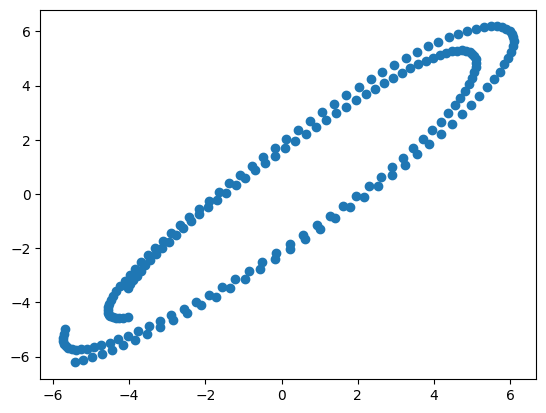

In [444]:

#print(project_modes(dmd_obj,dd['tphate']['test'].T).shape)
#projs = project_modes(dmd_obj,dd['tphate']['train'].T)
ax = plt.gca()
ax.scatter(dmd_obj[1][0][0,:],dmd_obj[1][0][1,:])
plt.show()
plt.close()

### load in data

In [570]:
dataset = 'Lorenz63' #other options: Van der Pol, Circles, DoubleSDE

if dataset == 'Lorenz63':
    dsname='Lorenz63_16d'
    fn = 'Lorenz63_16d_spikified.h5'
    gen = None
    latent_dim=4
    
elif dataset == 'Van der Pol':
    dsname='Vanderpol_16d'
    fn = 'Vanderpol_16d_spikified.h5'
    gen = Vanderpol()
    latent_dim=3
    
elif dataset == 'Circles':
    dsname='Circles_16d'
    fn = 'Circles_16d_spikified.h5'
    gen=DoubleCircles()
    latent_dim=3

elif dataset == 'DoubleSDE':
    dsname = 'DoubleSDE_16d'
    fn = 'Doublesde_16d_spikified.h5'
    gen = DoubleSDE()
    latent_dim=3
else:
    raise NotImplementedError

In [571]:
import h5py
import os
datadir = '/home/miles/isilon/All_Staff/common_datasets/toys' # replace with path to isilon
print(os.path.isdir(datadir))
print(fn)
with h5py.File(os.path.join(datadir,fn),'r') as f:
    print(list(f.keys()))
    gt_train,gt_test = f['train_gt'][()], f['valid_gt'][()]
    gt_train_proj,gt_test_proj = f['train_truth'][()],f['valid_truth'][()]
    lfads_train_e,lfads_test_e = f['train_lfads_factors'][()],f['valid_lfads_factors'][()]
    lfads_train_r,lfads_test_r = f['train_lfads_rates'][()],f['valid_lfads_rates'][()]



True
Lorenz63_16d_spikified.h5
['conversion_factor', 'train_data', 'train_dynamics', 'train_gt', 'train_lfads_factors', 'train_lfads_rates', 'train_truth', 'valid_data', 'valid_dynamics', 'valid_gt', 'valid_lfads_factors', 'valid_lfads_rates', 'valid_truth']


### lfads validation pictures

In [572]:
print(lfads_train_e.shape)
print(lfads_train_r.shape)
print(gt_train_proj.shape)

(1248, 100, 4)
(1248, 100, 16)
(1248, 100, 16)


[0.0195797  0.01166752 0.05306232 0.01136693 0.04193217 0.1106299
 0.02775933 0.02375646 0.02557137 0.15877897 0.02653245 0.13776649
 0.04044904 0.01549972 2.37719391 0.07875227]
[0.03190565 0.01459641 0.04829337 0.00475715 0.00821142 0.00378295
 0.00695361 0.05741182 0.0055318  0.00140481 0.06072591 0.06687175
 0.02992151 0.01452943 0.00080657 0.04106588]


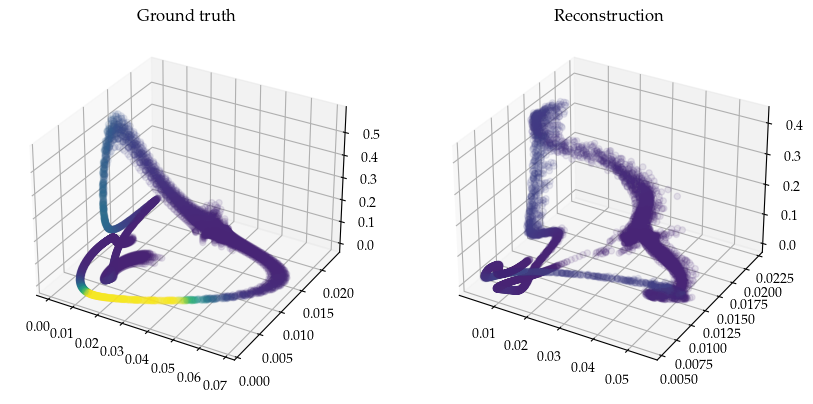

In [573]:
from matplotlib import colors
import matplotlib.pyplot as plt
import numpy as np
norm = colors.Normalize(vmin=-1,vmax=10)
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(10,5),subplot_kw={'projection':'3d'})


for t1,t2 in zip(gt_train_proj[:100],lfads_train_r[:100]):
    axs[0].scatter(t1[:,0],t1[:,1],t1[:,2],cmap='viridis',c=np.linalg.norm(t1,axis=-1),norm=norm,alpha=0.1)
    axs[1].scatter(t2[:,0],t2[:,1],t2[:,2],cmap='viridis',c=np.linalg.norm(t2,axis=-1),norm=norm,alpha=0.1)

print(np.nanmean(gt_test_proj,axis=(0,1)))
print(lfads_test_r[0,0,:])
axs[0].set_title("Ground truth")
axs[1].set_title("Reconstruction")
plt.show()
plt.close()

(31200, 3)


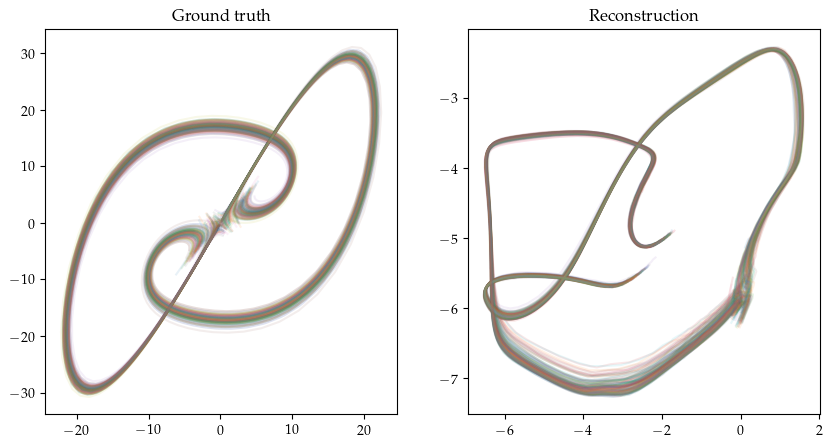

In [574]:

norm = colors.Normalize(vmin=-1,vmax=6)
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(10,5),subplot_kw={'projection':None})

stacked_test = np.reshape(gt_test,(-1,gt_test.shape[-1]))
print(stacked_test.shape)

for t1,t2 in zip(gt_test,lfads_test_e):
    axs[0].plot(t1[:,0],t1[:,1],alpha=0.1)#,cmap='viridis',c=np.linalg.norm(t1,axis=-1),norm=norm)
    axs[1].plot(t2[:,0],t2[:,1],alpha=0.1)#,cmap='viridis',c=np.linalg.norm(t2,axis=-1),norm=norm)
#for ii in range(0,len(stacked_test),100):
    #print(ii*100,(ii+1)*100)
#    axs[1].plot(stacked_test[ii:ii+100,0],stacked_test[ii:ii+100,1])

axs[0].set_title("Ground truth")
axs[1].set_title("Reconstruction")
plt.show()
plt.close()

### Format all data correctly

In [575]:
dd = format_data_comparisons(gt_train_proj,gt_test_proj,gt_train,gt_test,T=1,dt=0.01,name=dsname,latent_dim=latent_dim)

In [576]:
print(dsname)

Lorenz63_16d


### train all models

In [ ]:
models,train_es, test_es = compare_models(dd)

/home/miles/anaconda3/envs/flow_env/lib/python3.8/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 8.322330724926712e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


training dmd
(4000, 16)
(16, 16)
(16,)
(16, 4000)
(16, 16)
(16,)
(16, 4000)
training vae


training model:   1%| | 4/601 [00:10<25:44

### plot all embeddings

In [ ]:
%matplotlib inline
plot_models(np.stack(train_es[0],axis=0),*(train_es[1:]+[lfads_train_e]),names=['VAE', 'CEBRA','DMD','T-PHATE','LFADS'],\
           label=f'/home/miles/isilon/All_Staff/miles/comparison_models/all_models_{dsname}_train.svg',generator=gen)

In [ ]:
plot_models(np.stack(test_es[0],axis=0),*(test_es[1:]+[lfads_test_e]),names=['VAE', 'CEBRA','DMD','T-PHATE','LFADS'],\
           label=f'/home/miles/isilon/All_Staff/miles/comparison_models/all_models_{dsname}_test.svg',generator=gen)